<a href="https://colab.research.google.com/github/Hostfs/Pytorch/blob/main/01_pytorch_cnn_intro_cifar10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PyTorch CNN 입문 실습: CIFAR-10

## 실습 목표
- PyTorch로 이미지 분류 모델을 처음부터 학습하는 전체 흐름을 익힙니다.
- `Dataset`, `DataLoader`, `nn.Module`, `loss`, `optimizer`, `train/eval`의 역할을 이해합니다.
- 간단한 CNN을 직접 만들고 `CIFAR-10` 데이터셋에서 학습과 예측을 수행합니다.

## 이번 실습의 학습 방식: 지도학습(Supervised Learning)
- 이번 실습은 `지도학습(supervised learning)` 예제입니다.
- 지도학습이란, 입력 데이터와 함께 그에 대응하는 `정답(label)`이 주어진 상태에서 모델을 학습시키는 방식입니다.
- 예를 들어 고양이 사진에는 `cat`, 자동차 사진에는 `automobile` 같은 정답 라벨이 함께 주어집니다.
- 모델은 입력 이미지를 보고 정답 라벨을 맞히도록 학습되며, 예측과 정답의 차이를 줄이는 방향으로 가중치를 업데이트합니다.

## 오늘의 흐름
1. 환경과 라이브러리 확인
2. CIFAR-10 데이터셋 로드
3. 데이터 시각화
4. CNN 모델 정의
5. 학습 루프 작성
6. 테스트 성능 확인
7. 샘플 예측 결과 확인

> 이 노트북은 Colab 무료 GPU 기준으로 작성되었습니다.


In [ ]:
# 이 셀에서 하는 일:
# - 파이썬 버전과 PyTorch 버전을 확인합니다.
# - 현재 런타임에서 GPU를 사용할 수 있는지 확인합니다.

# sys는 현재 파이썬 실행 환경 정보를 확인할 때 사용합니다.
import sys
# torch는 PyTorch의 핵심 라이브러리로 Tensor 연산과 GPU 사용에 필요합니다.
import torch
# torchvision은 비전용 데이터셋, 전처리, 모델 유틸리티를 제공합니다.
import torchvision

print(f'Python version: {sys.version}')
print(f'PyTorch version: {torch.__version__}')
print(f'torchvision version: {torchvision.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')

if torch.cuda.is_available():
    print(f'GPU name: {torch.cuda.get_device_name(0)}')


Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch version: 2.10.0+cu128
torchvision version: 0.25.0+cu128
CUDA available: True
GPU name: Tesla T4


## 1. 라이브러리 불러오기

이제 실습에 필요한 라이브러리를 불러오겠습니다. 시각화를 위해 `matplotlib`도 함께 사용합니다.


In [ ]:
# 이 셀에서 하는 일:
# - 학습과 시각화에 필요한 라이브러리를 불러옵니다.
# - 재현 가능한 결과를 위해 시드를 고정합니다.

# random은 파이썬 기본 난수 라이브러리로, 시드 고정에 사용합니다.
import random
# numpy는 숫자 배열을 다루고 시드를 함께 고정할 때 사용합니다.
import numpy as np
# matplotlib는 이미지와 학습 결과를 시각화할 때 사용합니다.
import matplotlib.pyplot as plt

# nn은 신경망 레이어와 손실 함수를 정의할 때 사용합니다.
from torch import nn
# DataLoader는 데이터를 배치 단위로 묶어 학습 루프에 전달합니다.
from torch.utils.data import DataLoader
# datasets는 예제 데이터셋을 쉽게 불러오고, transforms는 이미지 전처리에 사용합니다.
from torchvision import datasets, transforms

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

plt.rcParams['figure.figsize'] = (10, 4)


In [ ]:
# 이 셀에서 하는 일:
# - 연산에 사용할 device를 정합니다.
# - GPU가 있으면 GPU를 사용하고, 없으면 CPU를 사용합니다.

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'사용할 device: {device}')


사용할 device: cuda


## 2. CIFAR-10 데이터셋 준비

`CIFAR-10`은 10개 클래스의 작은 컬러 이미지 데이터셋입니다. 이미지 크기는 `32x32`, 채널 수는 `3(RGB)`입니다.

이 데이터셋은 지도학습 예제로 자주 사용됩니다. 즉, 각 이미지에는 미리 정답 클래스가 붙어 있습니다.
우리는 `이미지`를 입력으로 넣고, `정답 라벨`과 비교하면서 모델이 올바른 클래스를 맞히도록 학습시킵니다.

이번 실습에서는 다음 전처리를 적용합니다.
- `ToTensor()`: PIL 이미지를 PyTorch Tensor로 변환
- `Normalize(...)`: 각 채널 값을 정규화해 학습을 조금 더 안정적으로 만듦

### 선택: Google Drive 백업 데이터 사용

실습 현장에서 인터넷 상태가 좋지 않으면 `CIFAR-10` 다운로드가 느리거나 실패할 수 있습니다.

그래서 아래 코드 셀은 **선택용 백업 블록**으로 넣어두었습니다.
- 평소에는 `USE_DRIVE_BACKUP = False` 그대로 둡니다.
- 미리 Google Drive에 `cifar-10-batches-py` 폴더 또는 `cifar-10-python.tar.gz` 파일을 올려둔 경우,
- 실습 현장에서는 `USE_DRIVE_BACKUP = True`로 바꿔서 Drive에서 바로 복사해 사용할 수 있습니다.


In [ ]:
# 이 셀에서 하는 일:
# - 선택적으로 Google Drive에 미리 올려둔 CIFAR-10 데이터를 /content/data로 복사합니다.
# - 네트워크 상황이 좋지 않을 때만 USE_DRIVE_BACKUP 값을 True로 바꿔 사용하세요.

from pathlib import Path
import os
import shutil
import tarfile

# 기본 데이터 저장 경로입니다.
DATA_ROOT = './data'

# 필요할 때만 True로 바꿔 사용합니다.
USE_DRIVE_BACKUP = False

# 예시 경로입니다. 실제 강의 준비 시 Drive 경로에 맞게 수정하면 됩니다.
DRIVE_FOLDER_PATH = '/content/drive/MyDrive/pytorch_datasets/cifar-10-batches-py'
DRIVE_ARCHIVE_PATH = '/content/drive/MyDrive/pytorch_datasets/cifar-10-python.tar.gz'

Path(DATA_ROOT).mkdir(parents=True, exist_ok=True)

if USE_DRIVE_BACKUP:
    # Colab에서 Google Drive를 마운트합니다.
    from google.colab import drive
    drive.mount('/content/drive')

    target_folder = os.path.join(DATA_ROOT, 'cifar-10-batches-py')
    target_archive = os.path.join(DATA_ROOT, 'cifar-10-python.tar.gz')

    if os.path.isdir(DRIVE_FOLDER_PATH):
        # Drive에 압축이 풀린 폴더가 있으면 그대로 복사합니다.
        if os.path.exists(target_folder):
            shutil.rmtree(target_folder)
        shutil.copytree(DRIVE_FOLDER_PATH, target_folder)
        print('Drive 폴더에서 CIFAR-10 데이터를 복사했습니다.')
    elif os.path.isfile(DRIVE_ARCHIVE_PATH):
        # Drive에 tar.gz 파일이 있으면 복사 후 압축을 풉니다.
        shutil.copy2(DRIVE_ARCHIVE_PATH, target_archive)
        with tarfile.open(target_archive, 'r:gz') as tar:
            tar.extractall(DATA_ROOT)
        print('Drive 압축 파일에서 CIFAR-10 데이터를 복사하고 압축을 해제했습니다.')
    else:
        raise FileNotFoundError('Drive에서 CIFAR-10 백업 데이터를 찾지 못했습니다. 경로를 확인하세요.')
else:
    print('기본 다운로드 방식을 사용합니다. 필요 시 USE_DRIVE_BACKUP를 True로 바꾸세요.')


기본 다운로드 방식을 사용합니다. 필요 시 USE_DRIVE_BACKUP를 True로 바꾸세요.


In [ ]:
# 이 셀에서 하는 일:
# - 먼저 transform이 없는 원본 데이터셋을 다운로드합니다.
# - 그 다음 학습용 transform을 정의하고, 전처리된 데이터셋도 따로 만듭니다.

transform = transforms.Compose([
    # 이미지를 Tensor로 바꿉니다.
    transforms.ToTensor(),
    # RGB 각 채널을 평균 0, 표준편차 1 근처로 정규화합니다.
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

raw_train_dataset = datasets.CIFAR10(
    root=DATA_ROOT,
    train=True,
    download=not USE_DRIVE_BACKUP,
    transform=None,
)

raw_test_dataset = datasets.CIFAR10(
    root=DATA_ROOT,
    train=False,
    download=not USE_DRIVE_BACKUP,
    transform=None,
)

train_dataset = datasets.CIFAR10(
    root=DATA_ROOT,
    train=True,
    download=False,
    transform=transform,
)

test_dataset = datasets.CIFAR10(
    root=DATA_ROOT,
    train=False,
    download=False,
    transform=transform,
)

print(f'train 데이터 개수: {len(train_dataset):,}')
print(f'test 데이터 개수: {len(test_dataset):,}')


100%|██████████| 170M/170M [00:24<00:00, 7.01MB/s]


train 데이터 개수: 50,000
test 데이터 개수: 10,000


In [ ]:
# 이 셀에서 하는 일:
# - DataLoader를 만들어 배치 단위로 데이터를 꺼낼 수 있게 합니다.

BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
)

class_names = train_dataset.classes
print(class_names)


['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## 3. 원본 데이터 먼저 보기

전처리를 적용하기 전에, 원본 `PIL 이미지`가 실제로 어떻게 생겼는지 먼저 확인해보겠습니다.

이 단계는 매우 중요합니다.
- 이미지가 컬러인지 흑백인지
- 해상도가 어느 정도인지
- 클래스별 예시가 직관적으로 구분되는지

이런 감각을 먼저 가져야, 이후 `Tensor 변환`과 `정규화`가 왜 필요한지도 더 자연스럽게 이해할 수 있습니다.


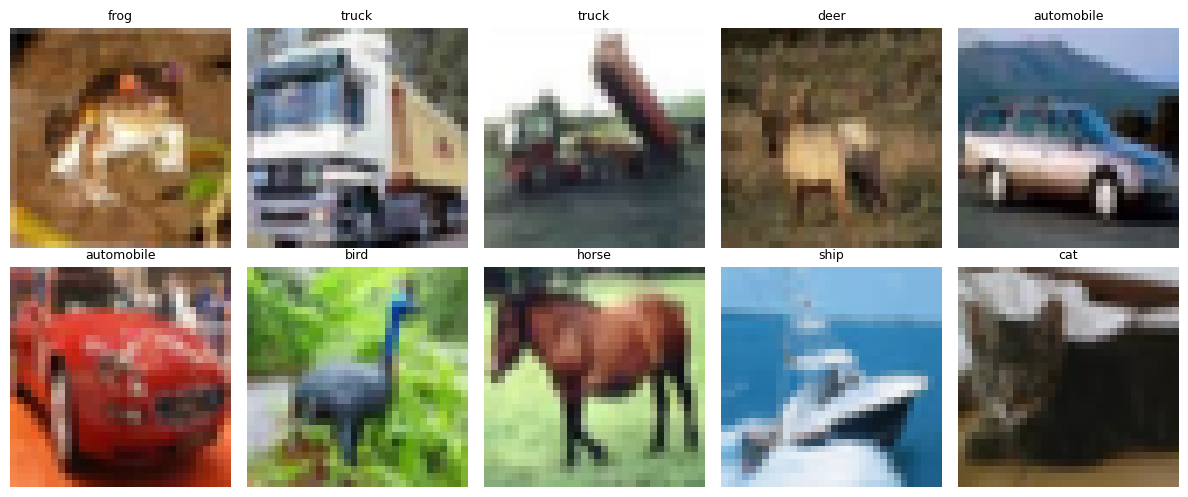

In [ ]:
# 이 셀에서 하는 일:
# - transform이 적용되기 전의 원본 PIL 이미지를 직접 시각화합니다.
# - 아직 Tensor로 바꾸기 전이라, 이미지가 사람이 보는 형태 그대로 보입니다.

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    image, label = raw_train_dataset[i]
    ax.imshow(image)
    ax.set_title(raw_train_dataset.classes[label], fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()


## 4. 데이터 확인하기

이제는 전처리와 정규화가 적용된 뒤의 배치 데이터를 확인해보겠습니다.

즉, 바로 위에서는 `원본 PIL 이미지`를 봤고, 이제는 `Tensor + Normalize`가 적용된 데이터를 다시 사람이 보기 좋게 복원해서 확인합니다.


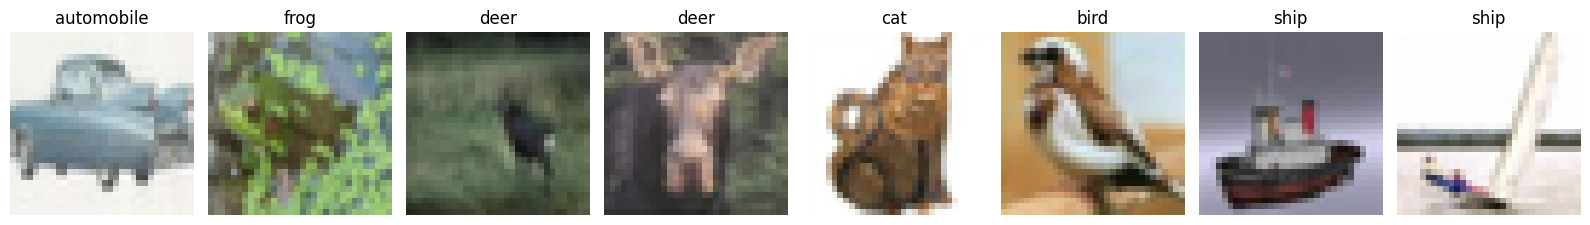

In [ ]:
# 이 셀에서 하는 일:
# - 정규화된 이미지를 다시 사람이 보기 좋은 범위로 바꿔 시각화합니다.
# - 여러 장의 샘플 이미지와 클래스 이름을 함께 확인합니다.

def show_images(images, labels, class_names, n=8):
    # Tensor를 CPU로 옮기고 numpy 형태로 바꿉니다.
    images = images[:n].cpu()
    labels = labels[:n].cpu()

    fig, axes = plt.subplots(1, n, figsize=(16, 3))

    for i in range(n):
        # 정규화 이전 범위로 복원합니다.
        img = images[i] * 0.5 + 0.5
        # 채널 순서를 (C, H, W) -> (H, W, C)로 바꿉니다.
        img = img.permute(1, 2, 0).numpy()
        axes[i].imshow(img)
        axes[i].set_title(class_names[labels[i].item()])
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

sample_images, sample_labels = next(iter(train_loader))
show_images(sample_images, sample_labels, class_names)


## 5. CNN 모델 정의

이번에는 간단한 CNN을 직접 만듭니다.

- `Conv2d`: 이미지에서 특징을 추출
- `ReLU`: 비선형성 추가
- `MaxPool2d`: 공간 크기를 줄여 계산량 감소
- `Linear`: 마지막 분류 수행


In [ ]:
# 이 셀에서 하는 일:
# - 간단한 CNN 분류 모델을 정의합니다.
# - 입력은 3채널 컬러 이미지이고, 출력은 10개 클래스 점수입니다.

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        # 첫 번째 합성곱 블록입니다.
        self.features = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        # 32x32 이미지는 세 번의 pooling 후 4x4 크기가 됩니다.
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        # 합성곱 블록을 통과시키며 특징 맵을 만듭니다.
        x = self.features(x)
        # 마지막에 완전연결층으로 분류 점수를 만듭니다.
        x = self.classifier(x)
        return x

model = SimpleCNN(num_classes=10).to(device)
print(model)


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)


## 6. 손실 함수와 옵티마이저 정의

- `CrossEntropyLoss`: 다중 클래스 분류에서 자주 쓰는 손실 함수
- `Adam`: 학습률을 자동으로 조절하며 잘 동작하는 대표적인 옵티마이저


In [ ]:
# 이 셀에서 하는 일:
# - 손실 함수와 옵티마이저를 정의합니다.
# - 학습 epoch 수를 정합니다.

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
EPOCHS = 3

print(f'학습 epoch 수: {EPOCHS}')


학습 epoch 수: 3


## 7. 학습 함수 만들기

이 단계가 바로 지도학습이 실제로 일어나는 부분입니다.
모델은 `입력 이미지`를 보고 예측을 만들고, 그 예측을 `정답 라벨`과 비교한 뒤 틀린 정도(loss)를 계산합니다.
그 다음 loss를 줄이는 방향으로 모델의 가중치를 조금씩 업데이트합니다.

PyTorch 학습 루프의 핵심 순서는 다음과 같습니다.

1. 입력과 정답을 가져온다.
2. 예측값을 계산한다. (`forward`)
3. 손실을 계산한다.
4. 기울기를 초기화한다.
5. 역전파를 수행한다. (`backward`)
6. 가중치를 업데이트한다. (`step`)


In [ ]:
# 이 셀에서 하는 일:
# - 한 epoch 학습 함수와 평가 함수를 정의합니다.

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    # 모델을 학습 모드로 전환합니다.
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        # 데이터를 GPU 또는 CPU로 옮깁니다.
        images = images.to(device)
        labels = labels.to(device)

        # 이전 step의 gradient를 초기화합니다.
        optimizer.zero_grad()

        # 모델의 예측값을 계산합니다.
        outputs = model(images)

        # 예측값과 정답을 비교해 loss를 계산합니다.
        loss = criterion(outputs, labels)

        # 역전파를 수행해 gradient를 계산합니다.
        loss.backward()

        # gradient를 이용해 가중치를 업데이트합니다.
        optimizer.step()

        # 통계를 누적합니다.
        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def evaluate(model, dataloader, criterion, device):
    # 모델을 평가 모드로 전환합니다.
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    # 평가 시에는 gradient를 계산하지 않아 더 빠르고 메모리를 덜 사용합니다.
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


In [ ]:
# 이 셀에서 하는 일:
# - 여러 epoch 동안 실제 학습을 수행합니다.
# - train loss / train accuracy / test accuracy를 함께 출력합니다.

history = []

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    history.append({
        'epoch': epoch + 1,
        'train_loss': train_loss,
        'train_acc': train_acc,
        'test_loss': test_loss,
        'test_acc': test_acc,
    })

    print(
        f"[Epoch {epoch + 1}/{EPOCHS}] "
        f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
        f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}"
    )


[Epoch 1/3] train_loss=1.4626, train_acc=0.4696, test_loss=1.1612, test_acc=0.5816
[Epoch 2/3] train_loss=1.0343, train_acc=0.6324, test_loss=0.9875, test_acc=0.6602
[Epoch 3/3] train_loss=0.8407, train_acc=0.7031, test_loss=0.8439, test_acc=0.7068


## 8. 테스트 정확도 확인

이제 최종 테스트 정확도를 다시 한 번 정리해서 확인해보겠습니다.


In [ ]:
# 이 셀에서 하는 일:
# - 마지막 모델의 테스트 성능을 보기 좋게 출력합니다.

final_test_loss, final_test_acc = evaluate(model, test_loader, criterion, device)
print(f'최종 test loss: {final_test_loss:.4f}')
print(f'최종 test accuracy: {final_test_acc:.4%}')


최종 test loss: 0.8439
최종 test accuracy: 70.6800%


## 9. 예측 결과 시각화

정확도 숫자만 보는 것보다, 실제로 어떤 이미지를 어떻게 예측했는지 함께 보는 것이 중요합니다.


/tmp/ipykernel_2575/1377914629.py:32: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2575/1377914629.py:32: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2575/1377914629.py:32: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2575/1377914629.py:32: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3

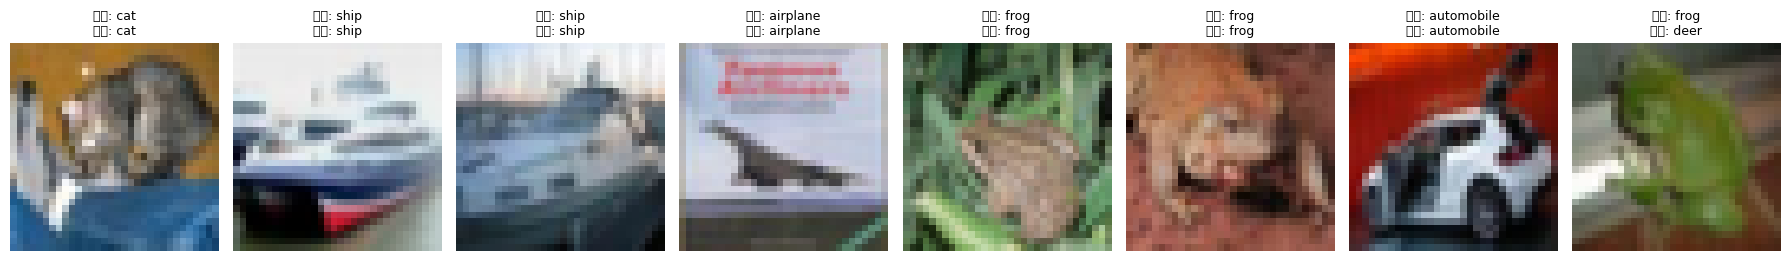

In [ ]:
# 이 셀에서 하는 일:
# - 테스트 이미지 몇 장에 대해 정답과 예측값을 함께 시각화합니다.

def predict_samples(model, dataloader, class_names, device, n=8):
    # 평가 모드로 전환합니다.
    model.eval()

    images, labels = next(iter(dataloader))
    images = images.to(device)
    labels = labels.to(device)

    with torch.no_grad():
        outputs = model(images)
        preds = outputs.argmax(dim=1)

    images = images[:n].cpu()
    labels = labels[:n].cpu()
    preds = preds[:n].cpu()

    fig, axes = plt.subplots(1, n, figsize=(18, 3))

    for i in range(n):
        img = images[i] * 0.5 + 0.5
        img = img.permute(1, 2, 0).numpy()
        axes[i].imshow(img)
        axes[i].set_title(
            f"정답: {class_names[labels[i].item()]}\n예측: {class_names[preds[i].item()]}",
            fontsize=9,
        )
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

predict_samples(model, test_loader, class_names, device, n=8)


## 핵심 정리

오늘 실습에서 확인한 핵심은 다음과 같습니다.

- `Dataset`은 데이터 한 개씩을 꺼내는 규칙을 담당합니다.
- `DataLoader`는 데이터를 배치 단위로 묶어 학습 루프에 전달합니다.
- `nn.Module`을 상속하면 모델 구조를 직접 정의할 수 있습니다.
- 학습 루프의 핵심은 `forward -> loss -> backward -> step`입니다.
- 테스트 단계에서는 `model.eval()`과 `torch.no_grad()`를 사용합니다.

다음 실습에서는 이 CNN 구조를 꽃 사진 분류 데이터셋 `Flowers102`에 적용해보고, pretrained `MobileViT-XSmall`을 fine-tuning 한 결과와 비교해보겠습니다.
